# Strategically Robust Trajectory Optimization

Each agent plans against the *worst* deviation the other agents could make, at
every step of the horizon. This notebook compares that with two baselines:

| method | collision cost evaluated at | weight |
|---|---|---|
| **nominal** | the planned trajectory | $c_1 = 2$ |
| **wider** | the planned trajectory | $c_1 = 5$ |
| **strategically robust** | the worst case, every step | $c_1 = 2$ |

"Wider" turns the penalty up instead of changing the model. If robustness were
only extra caution, wider would reproduce it. It does not.

Every solve uses **single shooting**: the controls are the only decision
variables, and the states come from rolling the dynamics forward. The notebook
runs in about a minute.

## 0. Setup

Makes the solver modules importable from the repository root or `notebooks/`.

In [1]:
import pathlib
import sys

ROOT = pathlib.Path.cwd()
if not (ROOT / 'solvers.py').exists():          # started from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FIGDIR = ROOT / 'figures'
FIGDIR.mkdir(exist_ok=True)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import benchmark_tables as bench
import plot_style
import plotting
from costs import ALPHA, C1_NOMINAL, C1_WIDER, make_cost
from solvers import (optimize_everystep_shooting, optimize_optimal_shooting,
                     split_solution)

plot_style.apply()
pd.set_option('display.precision', 4)

# Timed repetitions for section 6.  The paper uses 30 (10 at eight agents).
# Ratios are stable at these lower counts; absolute times are not.
BENCH_RUNS = 5
BENCH_RUNS_8 = 3

### The cost

Each agent tracks its goal and pays a penalty for being near any other agent:

$$
J = \sum_i \Big[ (x_{i,H} - x_i^f)^\top Q_f (x_{i,H} - x_i^f)
  + \sum_{t<H} (x_{i,t} - x_i^f)^\top Q (x_{i,t} - x_i^f) + u_{i,t}^\top R\, u_{i,t} \Big]
  \; + \sum_{i<j} \sum_t f\big(\|p_{i,t} - p_{j,t}\|\big)
$$

The pair cost is the log barrier $f(d) = -c_1 \log(d^2 + \alpha)$. `make_cost`
returns $f$ together with $f'$. Without $f'$, SLSQP falls back to finite
differences, which is slower and tends to stop at a worse point.

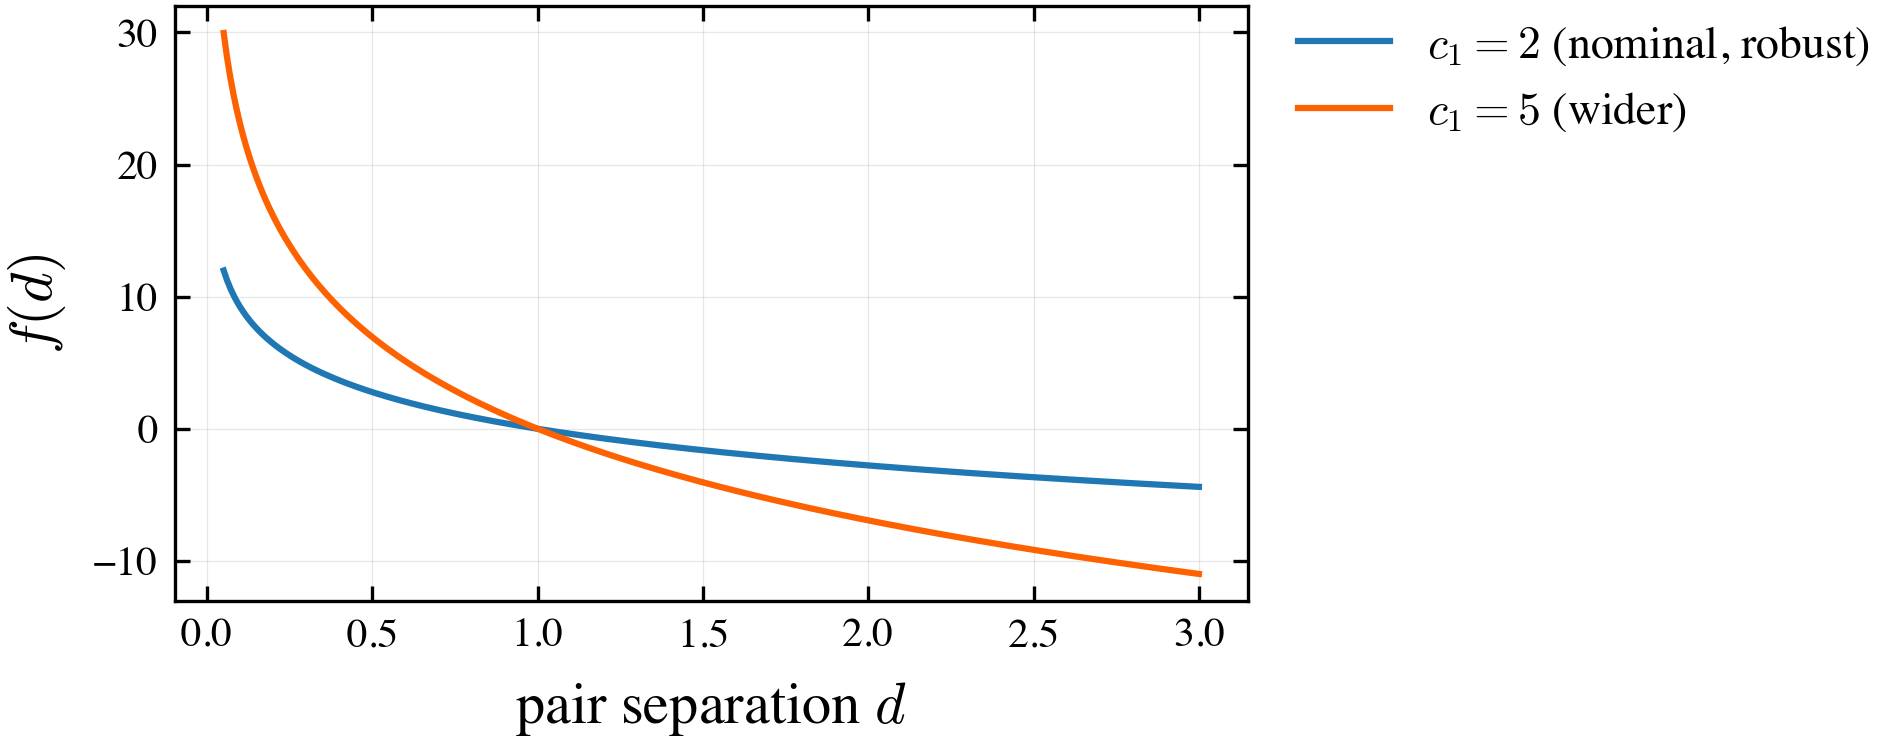

In [2]:
cost_nominal, grad_nominal = make_cost('logarithmic', c1=C1_NOMINAL, alpha=ALPHA)
cost_wider, grad_wider = make_cost('logarithmic', c1=C1_WIDER, alpha=ALPHA)

d = np.linspace(0.05, 3.0, 300)
fig, ax = plt.subplots(figsize=(plotting.PANEL * 1.3, plotting.PANEL * 0.8))
ax.plot(d, cost_nominal(d), color=plot_style.BLUE, label=f'$c_1 = {C1_NOMINAL:g}$ (nominal, robust)')
ax.plot(d, cost_wider(d), color=plot_style.ORANGE, label=f'$c_1 = {C1_WIDER:g}$ (wider)')
ax.set_xlabel('pair separation $d$')
ax.set_ylabel('$f(d)$')
ax.grid(True, linewidth=0.3, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)
fig.tight_layout()
plotting.legend_right(ax, fontsize=11)
plt.show()

## 1. Head-on: two agents swap places

Single integrators ($A = I$, $B = \Delta t\, I$), horizon $H = 20$ over 2 s.
The agents start 2 apart and swap places, so their straight-line plans
collide. The $\pm 0.05$ offset in $y$ breaks the mirror symmetry, which would
otherwise leave two equally good optima for the solver to pick between.

In [3]:
H, tf, eps = 20, 2.0, 2.0
dt = tf / H
n_a, sdim, cdim, pdim = 2, 2, 2, 2

A = np.eye(sdim)
B = dt * np.eye(cdim)
Q = np.eye(sdim)
Qf = 150.0 * np.eye(sdim)
R = np.eye(cdim)

x0 = np.array([[0.0, 0.95], [2.0, 1.05]])
xf = np.array([[2.0, 1.05], [0.0, 0.95]])

problem = (x0, xf, A, B, H, Q, R, Qf, n_a, sdim, cdim, pdim)
print(f'{n_a} agents, H = {H}, dt = {dt}, eps = {eps}')
print(f'full space:      {n_a * (H + 1) * sdim + n_a * H * cdim} variables, '
      f'{n_a * sdim + n_a * H * sdim} equality constraints')
print(f'single shooting: {n_a * H * cdim} variables, 0 equality constraints')

2 agents, H = 20, dt = 0.1, eps = 2.0
full space:      164 variables, 84 equality constraints
single shooting: 80 variables, 0 equality constraints


### The three solves

Wider and robust both start from the nominal solution.

In [4]:
import time

t0 = time.perf_counter()
res_nominal = optimize_optimal_shooting(*problem, cost_nominal,
                                        distance_cost_grad_func=grad_nominal)
t_nominal = time.perf_counter() - t0
x_nom, u_nom = split_solution(res_nominal, n_a, H, sdim, cdim)

t0 = time.perf_counter()
res_wider = optimize_optimal_shooting(*problem, cost_wider,
                                      distance_cost_grad_func=grad_wider, u_opt=u_nom)
t_wider = time.perf_counter() - t0

t0 = time.perf_counter()
res_robust = optimize_everystep_shooting(*problem, eps, cost_nominal,
                                         distance_cost_grad_func=grad_nominal,
                                         u_opt=u_nom)
t_robust = time.perf_counter() - t0

RESULTS = [res_nominal, res_wider, res_robust]
LABELS = ['nominal', 'wider', 'strat. robust']

pd.DataFrame([
    {'method': lab, 'objective': r.fun, 'iterations': r.nit,
     'function evals': r.nfev, 'seconds': t, 'converged': bool(r.success)}
    for lab, r, t in zip(LABELS, RESULTS, [t_nominal, t_wider, t_robust])
]).set_index('method')

,objective,iterations,function evals,seconds,converged
method,,,,,
nominal,73.3080,35,53,0.5897,True
wider,8.3905,13,23,0.0099,True
strat. robust,116.4260,12,23,0.1822,True


The objectives are **not comparable across rows**, since each method minimizes
a different function. The geometry is comparable, and the rest of the notebook
measures it.

## 2. Head-on summary

Two measures carry through the rest of the notebook:

- **worst case**: the separation left after an adversary with budget
  $\varepsilon = 2$ pushes the plan as hard as it can, at every step. The gap
  between a plan and its worst case is margin the adversary can erase.
- **path deviation**: the area between a method's trajectory and the nominal
  one, averaged over agents. It is what a method pays for its margin.

In the figure, color is the agent and dash pattern is the method.

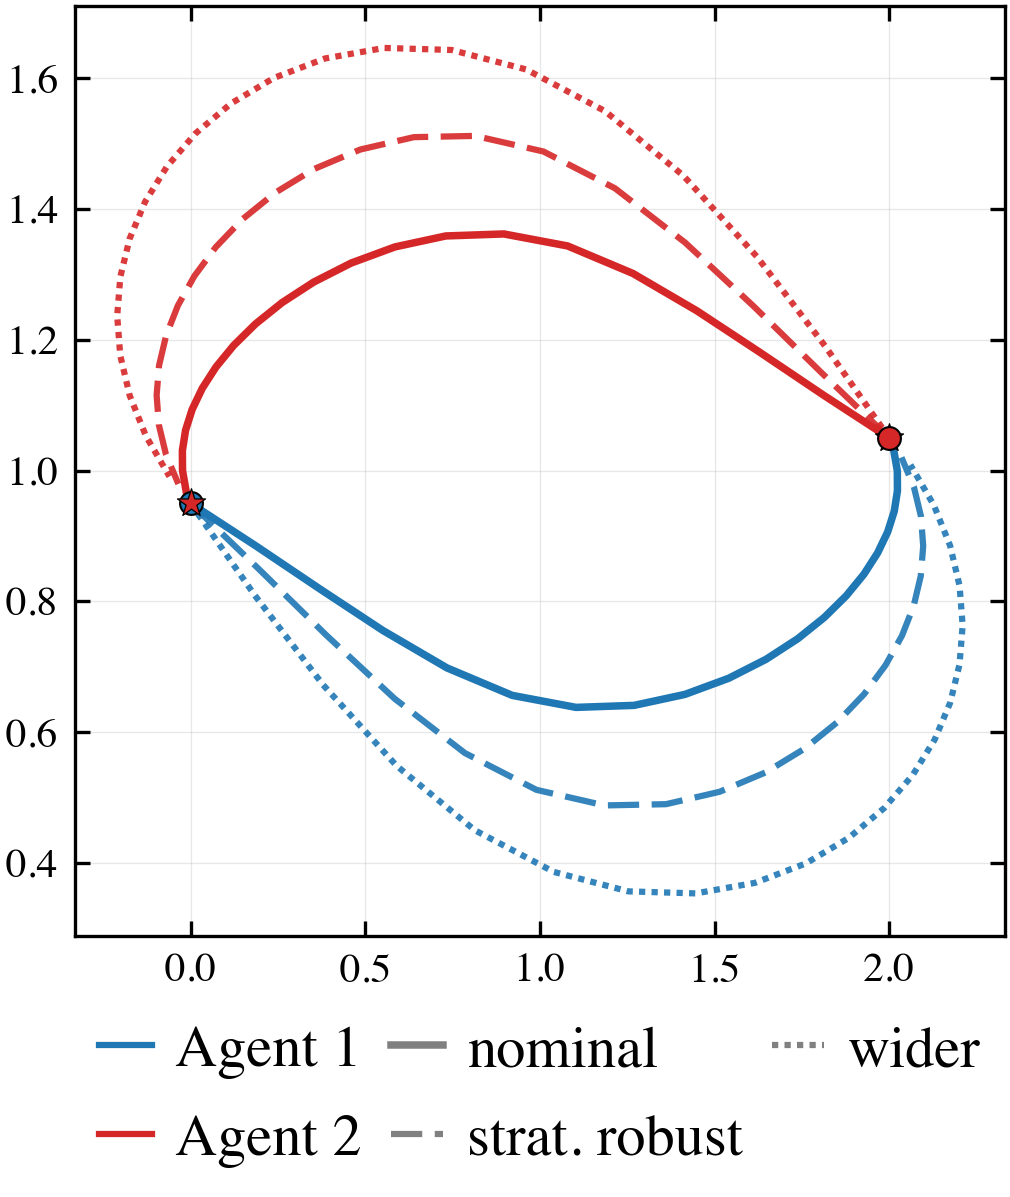

,min separation,"min separation, worst case",path deviation,worst-case gain,gain per unit deviation
method,,,,,
nominal,0.7056,0.2584,0.0000,0.0000,NaN
wider,1.1615,0.7615,0.5159,0.5032,0.9754
strat. robust,0.9649,0.5295,0.2523,0.2711,1.0747


In [5]:
def tradeoff_table(results, x_ref, n_agents):
    """Closest approach, as planned and worst case, against the deviation paid for it."""
    tab = pd.DataFrame(plotting.min_separation_table(
        results, LABELS, n_agents, H, sdim, cdim, pdim, eps, A, B)).set_index('method')
    tab['path deviation'] = [
        bench.integrated_path_deviation(split_solution(r, n_agents, H, sdim, cdim)[0],
                                        x_ref, dt, pdim) for r in results]
    gain = (tab['min separation, worst case']
            - tab.loc['nominal', 'min separation, worst case'])
    tab['worst-case gain'] = gain
    tab['gain per unit deviation'] = (
        gain / tab['path deviation']).replace([np.inf, -np.inf], np.nan)
    return tab


plotting.plot_trajectories(res_nominal, [res_robust, res_wider], n_a, H, sdim, cdim, xf,
                           method_labels=['nominal', 'strat. robust', 'wider'],
                           save_path=FIGDIR / 'headon_trajectories.png')
plt.show()

tradeoff_table(RESULTS, x_nom, n_a)

Both alternatives bow out further than nominal, and wider bows furthest. Robust
roughly doubles nominal's worst-case closest approach and wider nearly triples
it, at twice robust's path deviation. Per unit of deviation the two are within
about 10%.

The lasting difference is what sets the margin. Wider's comes from $c_1$, a
tuning constant with no physical meaning. Robust's comes from $\varepsilon$,
the disturbance energy the plan must absorb, stated up front in units.

The animation plays the robust plan over the faint nominal and wider paths. It
is saved as a GIF, which keeps the notebook far smaller than inline JavaScript.

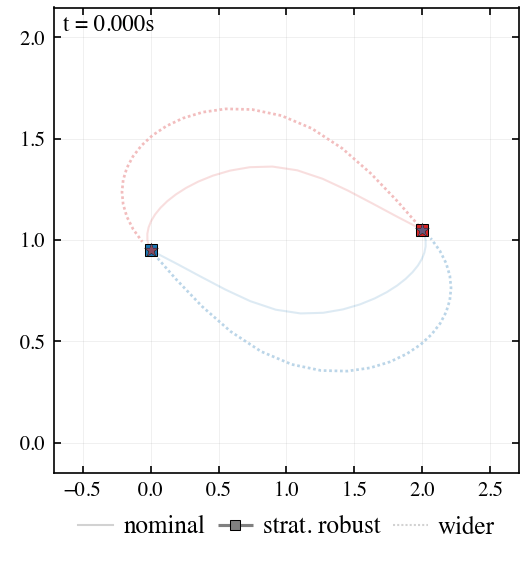

In [6]:
fig, anim = plotting.animate_trajectories(
    res_nominal, [res_robust, res_wider], n_a, H, sdim, cdim, xf, dt,
    method_labels=['nominal', 'strat. robust', 'wider'],
    save_path=FIGDIR / 'headon_animation.gif')
plt.close(fig)
display(Image(filename=str(FIGDIR / 'headon_animation.gif')))

## 3. Parallel: a conflict the nominal plan never sees

Two agents travel side by side, 2 apart, and never approach. The barrier is
essentially inactive and the nominal solve is easy. Give the adversary a
budget, though, and a conflict appears that the nominal model cannot express.

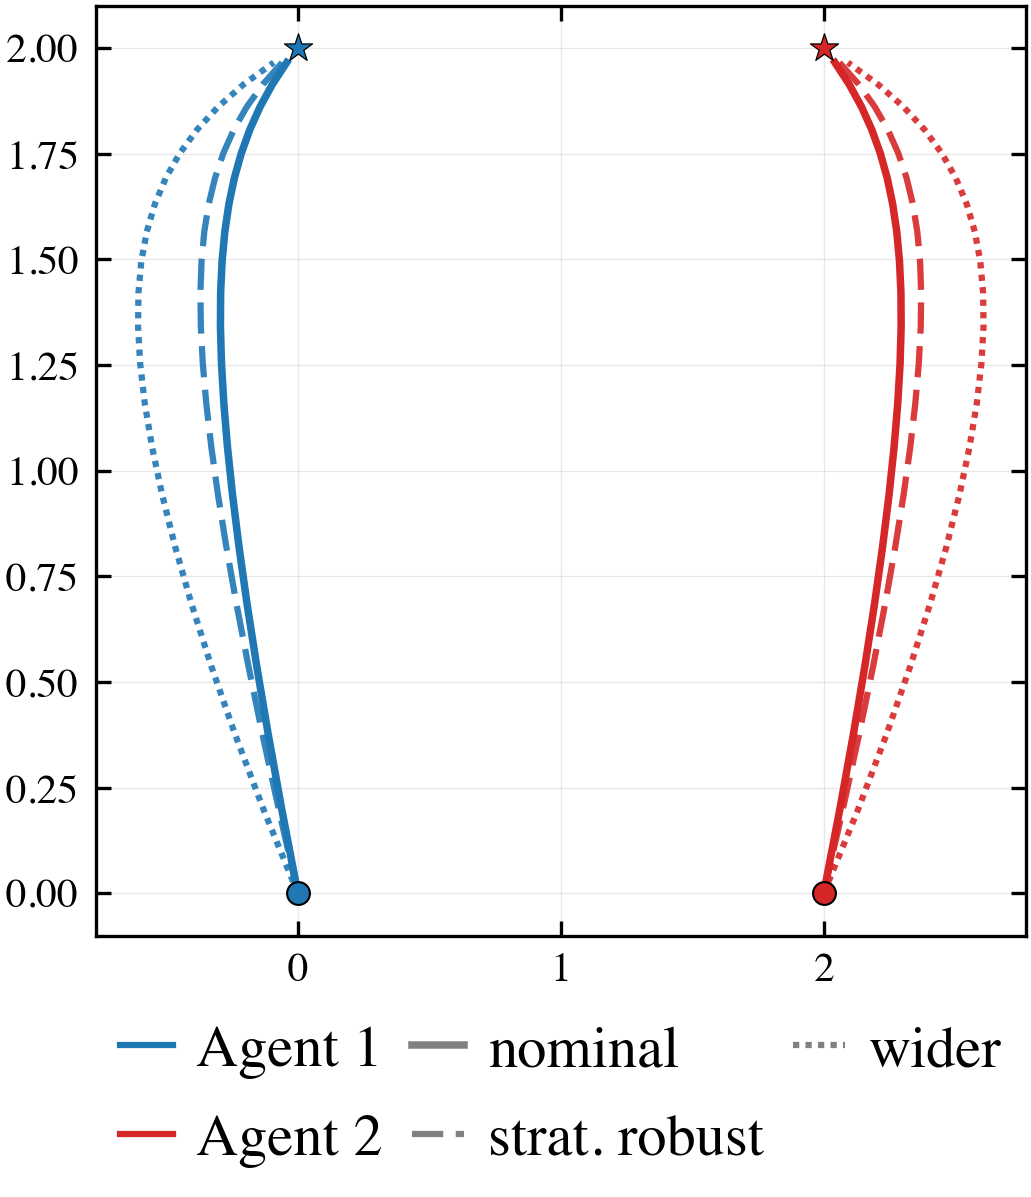

,min separation,"min separation, worst case",path deviation,worst-case gain,gain per unit deviation
method,,,,,
nominal,2.0,1.1911,0.0000,0.0000,NaN
wider,2.0,1.2894,0.4488,0.0984,0.2192
strat. robust,2.0,1.2255,0.1091,0.0344,0.3155


In [7]:
x0_par = np.array([[0.0, 0.0], [2.0, 0.0]])
xf_par = np.array([[0.0, 2.0], [2.0, 2.0]])
problem_par = (x0_par, xf_par, A, B, H, Q, R, Qf, n_a, sdim, cdim, pdim)

res_par_nominal = optimize_optimal_shooting(*problem_par, cost_nominal,
                                            distance_cost_grad_func=grad_nominal)
x_par_nom, u_par_nom = split_solution(res_par_nominal, n_a, H, sdim, cdim)
res_par_wider = optimize_optimal_shooting(*problem_par, cost_wider,
                                          distance_cost_grad_func=grad_wider,
                                          u_opt=u_par_nom)
res_par_robust = optimize_everystep_shooting(*problem_par, eps, cost_nominal,
                                             distance_cost_grad_func=grad_nominal,
                                             u_opt=u_par_nom)
RESULTS_PAR = [res_par_nominal, res_par_wider, res_par_robust]

plotting.plot_trajectories(res_par_nominal, [res_par_robust, res_par_wider],
                           n_a, H, sdim, cdim, xf_par,
                           method_labels=['nominal', 'strat. robust', 'wider'],
                           save_path=FIGDIR / 'parallel_trajectories.png')
plt.show()

tradeoff_table(RESULTS_PAR, x_par_nom, n_a)

`min separation` is 2.0 for every method: the agents are never closer than at
the start. Every difference lives in the worst-case column. The nominal planner
is not careless, since by its own model there is no conflict.

Wider again buys more absolute margin at several times the deviation. Per unit
of deviation, though, robust now leads by far more than the ~10% seen head-on.

The easy nominal solve also explains this scenario's high runtime ratio in
section 6. The ratio is roughly `1 + robust_iterations / nominal_iterations`,
and here the nominal count is small.

As in the head-on case, the animation plays the robust plan over the faint
nominal and wider paths.

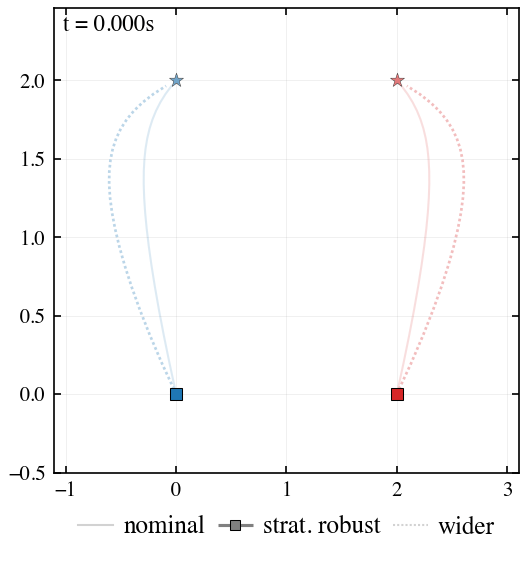

In [8]:
fig, anim = plotting.animate_trajectories(
    res_par_nominal, [res_par_robust, res_par_wider], n_a, H, sdim, cdim, xf_par, dt,
    method_labels=['nominal', 'strat. robust', 'wider'],
    save_path=FIGDIR / 'parallel_animation.gif')
plt.close(fig)
display(Image(filename=str(FIGDIR / 'parallel_animation.gif')))

## 4. Four agents

Six pairs, and each agent must resolve conflicts with several neighbours at
once. Only the scenario changes.

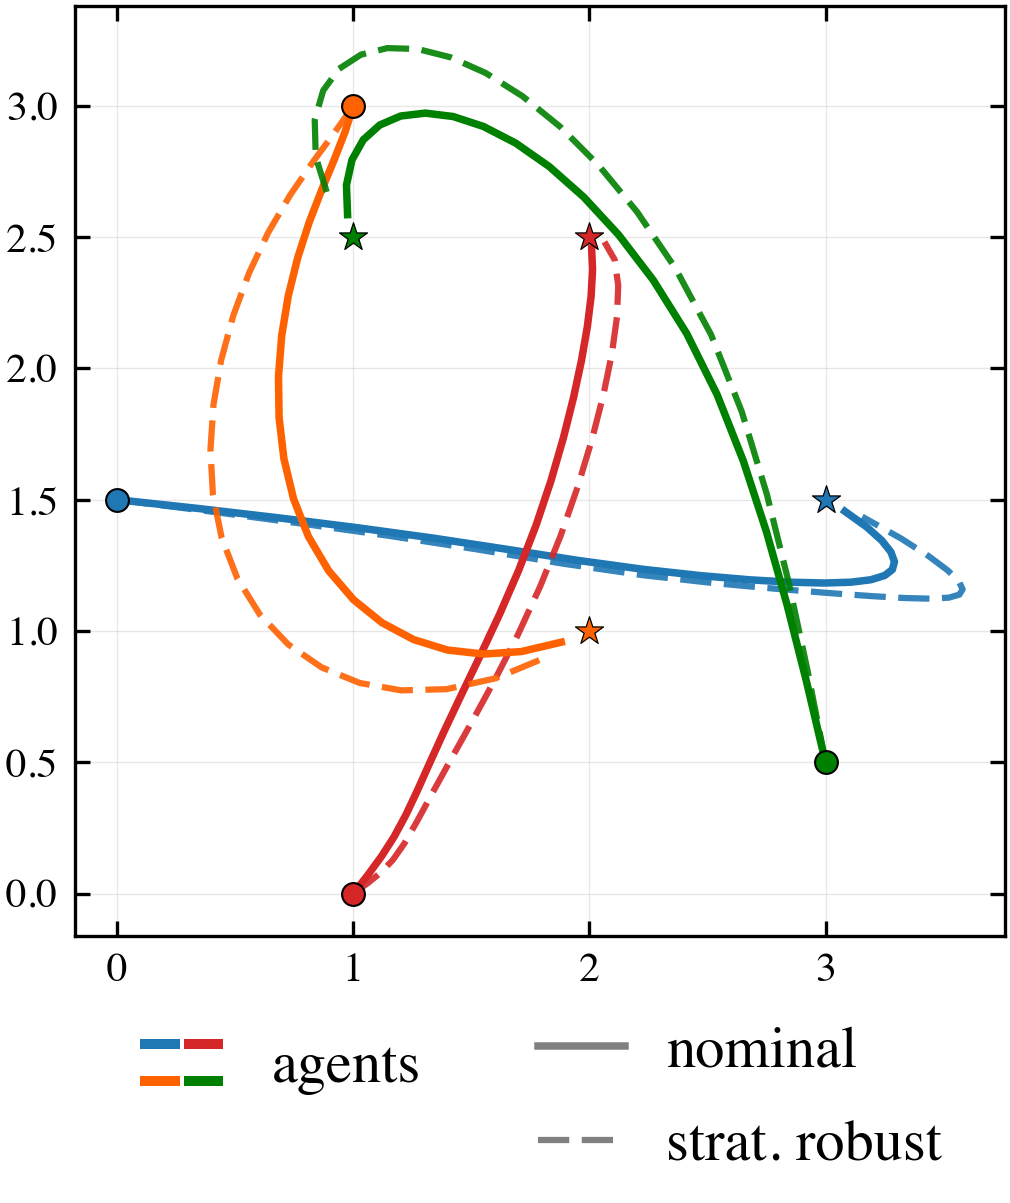

In [9]:
n_a4 = 4
x0_4 = np.array([[0.0, 1.5], [1.0, 0.0], [1.0, 3.0], [3.0, 0.5]])
xf_4 = np.array([[3.0, 1.5], [2.0, 2.5], [2.0, 1.0], [1.0, 2.5]])
problem4 = (x0_4, xf_4, A, B, H, Q, R, Qf, n_a4, sdim, cdim, pdim)

res4_nominal = optimize_optimal_shooting(*problem4, cost_nominal,
                                         distance_cost_grad_func=grad_nominal)
x4_nom, u4_nom = split_solution(res4_nominal, n_a4, H, sdim, cdim)
res4_wider = optimize_optimal_shooting(*problem4, cost_wider,
                                       distance_cost_grad_func=grad_wider, u_opt=u4_nom)
res4_robust = optimize_everystep_shooting(*problem4, eps, cost_nominal,
                                          distance_cost_grad_func=grad_nominal,
                                          u_opt=u4_nom)

# Wider is left off the plot (twelve more curves); the animation shows it faded.
plotting.plot_trajectories(res4_nominal, [res4_robust], n_a4, H, sdim, cdim, xf_4,
                           method_labels=['nominal', 'strat. robust'],
                           save_path=FIGDIR / '4agent_trajectories.png')
plt.show()

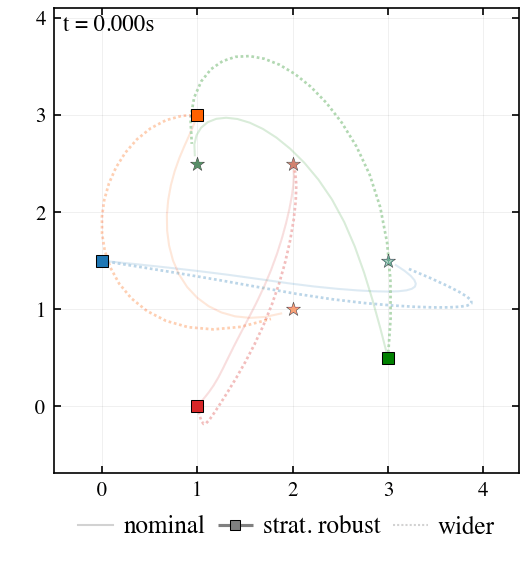

In [10]:
fig, anim = plotting.animate_trajectories(
    res4_nominal, [res4_robust, res4_wider], n_a4, H, sdim, cdim, xf_4, dt,
    method_labels=['nominal', 'strat. robust', 'wider'],
    save_path=FIGDIR / '4agent_animation.gif')
plt.close(fig)
display(Image(filename=str(FIGDIR / '4agent_animation.gif')))

## 5. Eight agents on a circle

Eight agents on a circle of radius 2 each head for the opposite point. Every
straight-line plan passes through the centre, so all 28 pairs conflict at once.
Warm-started, the robust solve is *faster* than the nominal solve it starts
from.

In [11]:
n_a8 = 8
angles = np.linspace(0, 2 * np.pi, n_a8, endpoint=False)
centre, radius = np.array([2.0, 2.0]), 2.0
x0_8 = np.array([centre + radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
xf_8 = np.array([centre - radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
problem8 = (x0_8, xf_8, A, B, H, Q, R, Qf, n_a8, sdim, cdim, pdim)

t0 = time.perf_counter()
res8_nominal = optimize_optimal_shooting(*problem8, cost_nominal,
                                         distance_cost_grad_func=grad_nominal)
t8_nominal = time.perf_counter() - t0
x8_nom, u8_nom = split_solution(res8_nominal, n_a8, H, sdim, cdim)

t0 = time.perf_counter()
res8_robust = optimize_everystep_shooting(*problem8, eps, cost_nominal,
                                          distance_cost_grad_func=grad_nominal,
                                          u_opt=u8_nom)
t8_robust = time.perf_counter() - t0

print(f'nominal: {t8_nominal:6.2f}s   robust (warm-started): {t8_robust:6.2f}s')

nominal:   2.14s   robust (warm-started):   0.97s


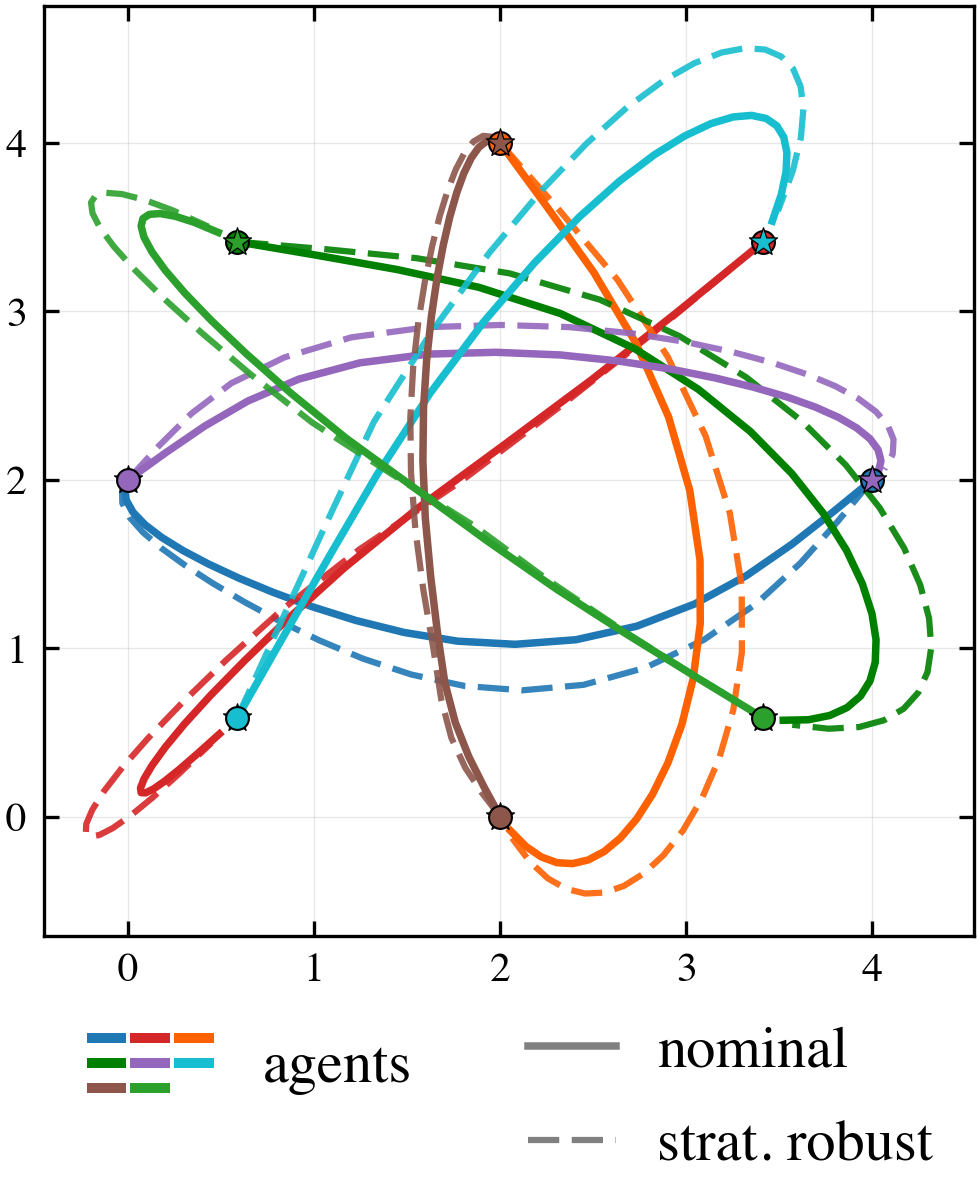

In [12]:
plotting.plot_trajectories(res8_nominal, [res8_robust], n_a8, H, sdim, cdim, xf_8,
                           method_labels=['nominal', 'strat. robust'],
                           save_path=FIGDIR / '8agent_trajectories.png')
plt.show()

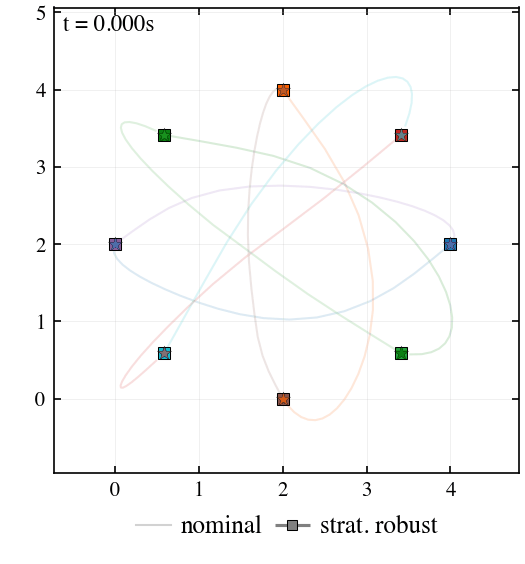

In [13]:
fig, anim = plotting.animate_trajectories(
    res8_nominal, [res8_robust], n_a8, H, sdim, cdim, xf_8, dt,
    method_labels=['nominal', 'strat. robust'],
    save_path=FIGDIR / '8agent_animation.gif')
plt.close(fig)
display(Image(filename=str(FIGDIR / '8agent_animation.gif')))

## 6. Runtime

`benchmark_tables.py` produces the paper's timing tables. It follows three
rules, each learned from a measurement that turned out wrong:

1. **Analytic gradients for every method.** A finite-difference baseline once
   stopped early at a worse optimum and inflated the 8-agent robust overhead
   from 1.29x to 3.72x.
2. **Median next to mean.** One outlier moved the 4-agent ratio from 1.89x to
   1.72x under the mean. The CV column flags noisy rows.
3. **One optimum per cell.** If the runs land on different local minima, the
   timing spread is not machine noise. The `uniq` column must be 1.

The robust time includes its nominal initialization, so the ratio is the full
cost of switching methods. `USE_SHOOTING` matches this notebook's solver.
Some ratios run higher than in the README's full-space table, where a
constrained QP that both methods share dominates each iteration and hides the
robust cost.

In [14]:
bench.USE_SHOOTING = True

results_bench = [bench.run_scenario(name, BENCH_RUNS, verbose=False)
                 for name in ('Head-on', 'Parallel', '4 agents')]
results_bench.append(bench.run_scenario('8 agents', BENCH_RUNS_8, verbose=False))

rows = []
for r in results_bench:
    s = bench.summarize(r)
    for method in ('nominal', 'wider', 'robust'):
        rows.append({
            'scenario': r['scenario'], 'n_a': r['n_a'],
            'method': bench.LABEL[method],
            'median (s)': s[method]['median'],
            'ratio': s[method]['ratio_median'],
            'CV': s[method]['cv'],
            'iterations': s[method]['nit'],
            'path deviation': r['deviation'][method],
            'objective': s[method]['objective'],
            'uniq': s[method]['objective_unique'],
        })
runtime = pd.DataFrame(rows).set_index(['scenario', 'method'])
runtime

n_a  median (s)   ratio      CV  iterations  \
scenario method                                                       
Head-on  Nominal          2      0.0260  1.0000  0.0116        35.0   
         Wider            2      0.0284  1.0913  0.0084        38.0   
         Strat. Robust    2      0.0363  1.3962  0.0038        12.0   
Parallel Nominal          2      0.0072  1.0000  0.0211         9.0   
         Wider            2      0.0078  1.0855  0.0124        10.0   
         Strat. Robust    2      0.0146  2.0409  0.0119         8.0   
4 agents Nominal          4      0.0825  1.0000  0.0132        25.0   
         Wider            4      0.0860  1.0418  0.0233        26.0   
         Strat. Robust    4      0.1605  1.9440  0.0524        20.0   
8 agents Nominal          8      2.1245  1.0000  0.0330        92.0   
         Wider            8      2.3220  1.0930  0.0040       101.0   
         Strat. Robust    8      3.1159  1.4667  0.0069        37.0   

                        path deviation  objective  uniq  
scenario method                                          
Head-on  Nominal                0.0000    73.3080     1  
         Wider                  0.5159     8.3905     1  
         Strat. Robust          0.2523   116.4260     1  
Parallel Nominal                0.0000    20.2524     1  
         Wider                  0.4488  -100.3461     1  
         Strat. Robust          0.1091    46.5736     1  
4 agents Nominal                0.0000   181.0621     1  
         Wider                  0.9532  -348.5486     1  
         Strat. Robust          0.4048   428.1921     1  
8 agents Nominal                0.0000    36.6866     1  
         Wider                  1.3681 -3389.7336     1  
         Strat. Robust          0.4109   884.7809     1

The headline is the `ratio` on the **Strat. Robust** rows: the end-to-end cost
of robustness as a multiple of nominal runtime.

In [15]:
print(bench.format_tables(results_bench, stat='median'))


### Head-on  (n=5, ratios by median, single shooting)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
---------------------------------------------------------------------------------------------
Nominal           0.0261   0.0260  0.0003  1.2%    35   1.00x     0.0000       73.3080     1
Wider             0.0283   0.0284  0.0002  0.8%    38   1.09x     0.5159        8.3905     1
Strat. Robust     0.0363   0.0363  0.0001  0.4%    12   1.40x     0.2523      116.4260     1

wall breakdown  measured overhead   total  share  per run
Nominal             0.13     0.05    0.18 33.4%    0.026
Wider               0.14     0.02    0.16 29.6%    0.028
Strat. Robust       0.18     0.02    0.20 36.9%    0.036
scenario total      0.45     0.09    0.55                  (unattributed +0.00s)

### Parallel  (n=5, ratios by median, single shooting)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
-----------------

---

**Further reading.** `adversary.py` documents the closed-form worst case. The
`README.md` appendix shows why the adversary's response drops out of the
gradient (the envelope theorem), which the paper does not derive.